<a href="https://colab.research.google.com/github/NadeemQazi/Modules/blob/master/LinearRegression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Year,Month,Interest_Rate,Unemployment_Rate,Stock_Index_Price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256
5,2017,7,2.50,5.6,1254
6,2017,6,2.50,5.5,1234
7,2017,5,2.25,5.5,1195
8,2017,4,2.25,5.5,1159
9,2017,3,2.25,5.6,1167


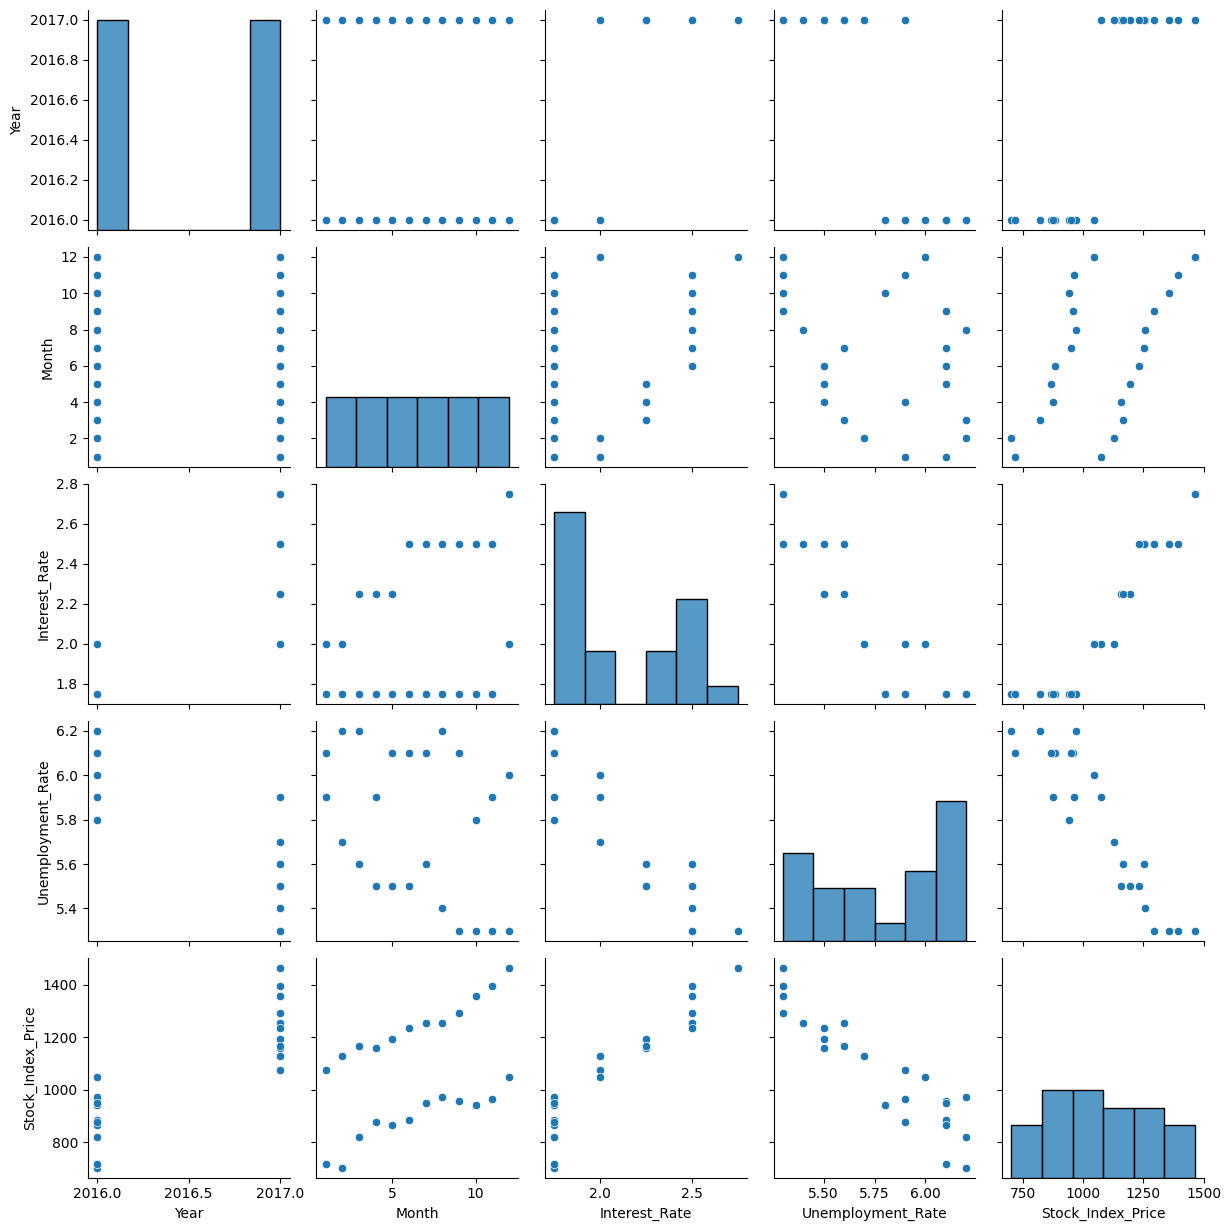

In [1]:
import pandas as pd
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
Stock_Market = {'Year': [2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016,2016],
                'Month': [12, 11,10,9,8,7,6,5,4,3,2,1,12,11,10,9,8,7,6,5,4,3,2,1],
                'Interest_Rate': [2.75,2.5,2.5,2.5,2.5,2.5,2.5,2.25,2.25,2.25,2,2,2,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75,1.75],
                'Unemployment_Rate': [5.3,5.3,5.3,5.3,5.4,5.6,5.5,5.5,5.5,5.6,5.7,5.9,6,5.9,5.8,6.1,6.2,6.1,6.1,6.1,5.9,6.2,6.2,6.1],
                'Stock_Index_Price': [1464,1394,1357,1293,1256,1254,1234,1195,1159,1167,1130,1075,1047,965,943,958,971,949,884,866,876,822,704,719]
                }

df = pd.DataFrame(Stock_Market,columns=['Year','Month','Interest_Rate','Unemployment_Rate','Stock_Index_Price'])
display(df)
df.corr()

sns.pairplot(df)
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np
X = df[['Interest_Rate','Unemployment_Rate']] # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['Stock_Index_Price']

# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(
X,
Y,
test_size=0.2,
random_state=42
)
# with sklearn
regr = linear_model.LinearRegression()
#regr.fit(X, Y)
regr.fit(x_train, y_train)
# Print the intercept and the slope of the model
print('Intercept: B0 \n', regr.intercept_)
print('Coefficients B1,B2: \n', regr.coef_)
# Define a set of predictions for y based on subset x_test
y_pred = regr.predict(x_test)

# Import module
from sklearn.metrics import mean_squared_error
# We pass the test values and the predicted values
mse = mean_squared_error(y_test, y_pred)
# Let's take the square root
rmse = np.sqrt(mse)
# Print the result
print('Root Mean Squared Error: ' + str(rmse))
# Import r2_score module
from sklearn.metrics import r2_score
# Print R2 Score
print(r2_score(y_test, y_pred))

mlr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
print("header")
print(mlr_diff.head())


Intercept: B0 
 2601.599844115359
Coefficients B1,B2: 
 [ 260.26126267 -360.55339049]
Root Mean Squared Error: 83.40926389351989
0.8254940547158574
header
    Actual value  Predicted value
8           1159      1204.144037
16           971       821.626033
0           1464      1406.385347
18           884       857.681372
11          1075       994.857366


# predicting using trained Model

In [10]:
# prediction with sklearn
New_Interest_Rate = 2.75
New_Unemployment_Rate = 5.3
print ('Predicted Stock Index Price: \n', regr.predict([[New_Interest_Rate ,New_Unemployment_Rate]]))

Predicted Stock Index Price: 
 [1406.38534684]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.linear_model import Ridge, Lasso
# ======================
# Ridge Regression
# ======================

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(x_train, y_train)

print("RIDGE REGRESSION")
print("Intercept:", ridge_model.intercept_)
print("Coefficients:", ridge_model.coef_)

ridge_pred = ridge_model.predict(x_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("RMSE:", ridge_rmse)
print("R2 Score:", r2_score(y_test, ridge_pred))

ridge_diff = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': ridge_pred
})

print(ridge_diff.head())

RIDGE REGRESSION
Intercept: 1979.1647835648096
Coefficients: [ 243.72992995 -246.72929414]
RMSE: 75.48552297562645
R2 Score: 0.8570747412198068
    Actual Value  Predicted Value
8           1159      1170.546008
16           971       875.970537
0           1464      1341.756832
18           884       900.643467
11          1075      1010.921808


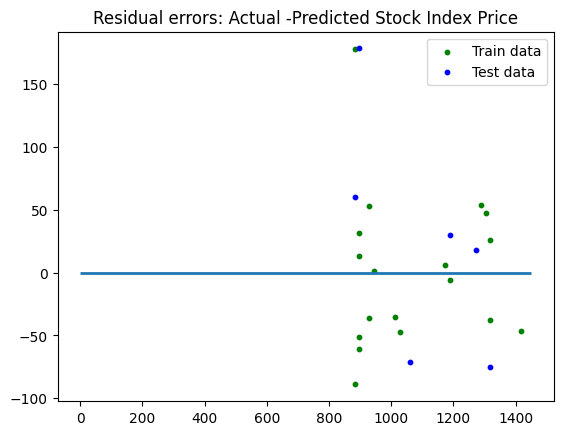

In [ ]:
import matplotlib.pyplot as plt
# plotting residual errors in training data
plt.scatter(regr.predict(x_train),
            regr.predict(x_train) - y_train,
            color="green", s=10,
            label='Train data')

# plotting residual errors in test data
plt.scatter(regr.predict(x_test),
            regr.predict(x_test) - y_test,
            color="blue", s=10,
            label='Test data')
# plotting line for zero residual error
plt.hlines(y=0, xmin=0, xmax=1450, linewidth=2)

# plotting legend
plt.legend(loc='upper right')

# plot title
plt.title("Residual errors: Actual -Predicted Stock Index Price")

# method call for showing the plot
plt.show()

#using the above model Write down the equation for the model and explain how the  Stock Price is related to Interest Rate and UnEmployment Rate .
# Looking at the Residual curver above , Comment how good the model is.?
2. Modify the code given in this notebook  and apply it to the  dataset provided in week 5
Submit your answer before the  9th December

# Repeat the Same exerise however using the  d